In [1]:
import xarray as xr
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import cartopy.crs as ccrs
import cartopy.feature as cfeat
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter
from dataclasses import dataclass
from typing import Any
import string
import cftime

from file_utils import *
from analysis_utils import *
from metpy.calc import divergence
from dask.distributed import Client, LocalCluster, progress

cluster = LocalCluster(n_workers=4, threads_per_worker=1)
client= Client(cluster)
print(client)

/home/eastinev/.conda/envs/climai/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Client: 'tcp://127.0.0.1:45369' processes=4 threads=4, memory=16.00 GiB>


In [2]:
LAT, LON = slice(35, 45), slice(-105, -85)
EXP = 'CTRL'
PANELS = [a + b + c for a, b, c in zip(['('] * 26, string.ascii_lowercase, [') '] * 26)]

def sel_JJA(ds):
    return ds.sel(time=ds.time.dt.month.isin([6, 7, 8]))

def sel_NGP(ds):
    return ds.sel(lat=LAT, lon=LON)

In [3]:
## Plot helpers
@dataclass
class PanelConfig:
    index: int
    name: str
    nrow: int
    ncol: int
    projection: None | ccrs.CRS = None
    fontsize: int = 12

    @property
    def add_x(self):
        return self.index in list(range(self.nrow * self.ncol))[-self.ncol:]

    @property
    def add_y(self):
        return (self.index % self.ncol) == 0

    @property
    def title(self):
        return PANELS[self.index] + self.name

def region_plot(
    data: xr.Dataset,
    ax: plt.Axes,
    cmap_kwargs: dict,
    panel: PanelConfig,
) -> (plt.Axes, Any):

    lats, lons = data.lat.data, data.lon.data
    lat_ticks = np.arange(lats[0], lats[-1] + 1, 5).tolist()
    dlon = 10 if int(lons[0]) == -110 else 5
    lon_ticks = np.arange(lons[0], lons[-1] + 1, dlon).tolist()
    extent = (lons[0], lons[-1], lats[0], lats[-1])
    ## believe the crs/transform should ALWAYS be PlateCarree.?
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    plt_obj = ax.contourf(lons, lats, data, transform=ccrs.PlateCarree(), **cmap_kwargs)
    ax.add_feature(cfeat.STATES, linewidth=0.25)
    configure_panel(ax, panel, lon_ticks, lat_ticks)

    return ax, plt_obj

def region_quiver_plot(winds: xr.Dataset, ax: plt.Axes) -> (plt.Axes, Any):
    lats, lons = winds.lat.data, winds.lon.data
    extent = (lons[0], lons[-1], lats[0], lats[-1])
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    plt_obj = ax.quiver(lons, lats, winds.U.data, winds.V.data, transform=ccrs.PlateCarree())
    ax.add_feature(cfeat.STATES, linewidth=0.5)
    return ax, plt_obj

def configure_panel(ax: plt.Axes, panel: PanelConfig, lon_ticks: list, lat_ticks: list) -> None:
    ax.set_title(panel.title, loc='left', fontsize=panel.fontsize)
    if panel.add_x: set_xticks(ax, lon_ticks, panel.projection)
    if panel.add_y: set_yticks(ax, lat_ticks, panel.projection)
    add_grid(ax, lat_ticks, lon_ticks)
    
def add_grid(ax, lat_ticks, lon_ticks):
    gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.xlocator = ticker.FixedLocator(lon_ticks)
    gl.ylocator= ticker.FixedLocator(lat_ticks)

def set_xticks(ax, lon_ticks, map_proj):
    if map_proj is None:
        ax.set_xticks(lon_ticks)
    else:
        ax.set_xticks(lon_ticks, crs=map_proj)
    lon_formatter = LongitudeFormatter(degree_symbol='')
    ax.xaxis.set_major_formatter(lon_formatter)

def set_yticks(ax, lat_ticks, map_proj):
    ax.set_yticks(lat_ticks, crs=map_proj)
    lat_formatter = LatitudeFormatter(degree_symbol='')
    ax.yaxis.set_major_formatter(lat_formatter)

In [4]:
# open surface pressure
ctrl_ps = sel_JJA(open_mf(
    f'/scratch/eastinev/cus_cesm/PS*.CTRL.nc',
    lat=LAT,
    lon=LON
))

warm_ps = sel_JJA(open_mf(
    f'/scratch/eastinev/cus_cesm/PS*.2K.nc',
    lat=LAT,
    lon=LON
))

def remove_nans(fields, ps):  # poorly named.. this is replacing the NaNs that were filled in for NN processing
    fields['plev'] = fields['plev'] * 100  # move to Pa
    fields = fields.where(fields.plev <= ps['PS'])  # return filled nan to nan
    return fields

In [5]:
# open met fields
ctrl_fields = sel_JJA(open_mf(
    f'/scratch/eastinev/cus_cesm/LSF*.CTRL.nc',
    drop_vars=['U', 'V'],
    lat=LAT,
    lon=LON
))
ctrl_fields = remove_nans(ctrl_fields, ctrl_ps)

warm_fields = sel_JJA(open_mf(
    f'/scratch/eastinev/cus_cesm/LSF*.2K.nc',
    drop_vars=['U', 'V'],
    lat=LAT,
    lon=LON
))
warm_fields = remove_nans(warm_fields, warm_ps)

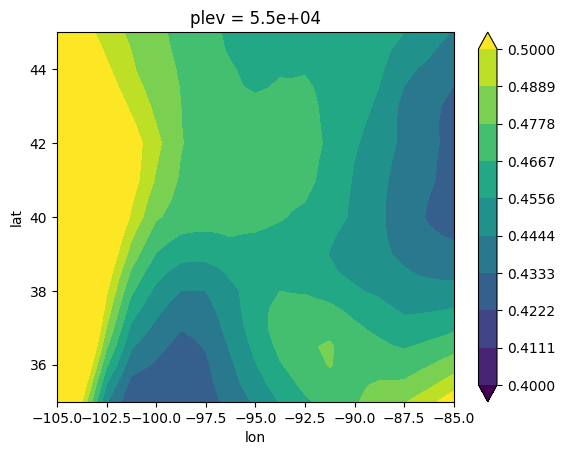

In [25]:
## does RH in CAM6 change?
ctrl_RH = (ctrl_fields.Q / calc_qsat(ctrl_fields.T, ctrl_fields.plev)).mean('time')
warm_RH = (warm_fields.Q / calc_qsat(warm_fields.T, warm_fields.plev)).mean('time')
ctrl_RH.isel(plev=11).plot.contourf(x='lon', y='lat', levels=np.linspace(0.4, 0.5, 10), extend='both')

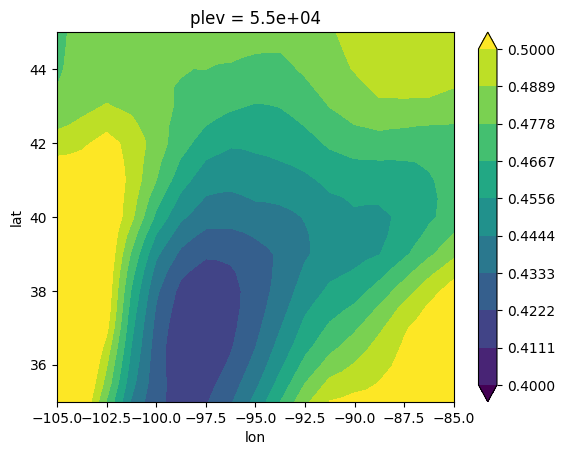

In [26]:
warm_RH.isel(plev=11).plot.contourf(x='lon', y='lat', levels=np.linspace(0.4, 0.5, 10), extend='both')

In [6]:
## open precip
ctrl_pr = sel_NGP(sel_JJA(xr.open_dataset(f'./CESM.CTRL_1979-1983.nc')))
warm_pr = sel_NGP(sel_JJA(xr.open_dataset(f'./CESM.2K_1979-1983.nc')))
# ctrl_pr = sel_NGP(sel_JJA(xr.open_dataset(f'./models/test2_JJA_F00h/MODEL_PRED_CESM.CTRL.nc')))
# warm_pr = sel_NGP(sel_JJA(xr.open_dataset(f'./models/test2_JJA_F00h/MODEL_PRED_CESM.2K.nc')))
# ctrl_pr = sel_NGP(sel_JJA(xr.open_dataset(f'./models/noQW_JJA_F00h/MODEL_PRED_CESM.CTRL.nc')))
# warm_pr = sel_NGP(sel_JJA(xr.open_dataset(f'./models/noQW_JJA_F00h/MODEL_PRED_CESM.2K.nc')))
# ctrl_pr = ctrl_pr.rename({'precip': 'PRECT'})
# warm_pr = warm_pr.rename({'precip': 'PRECT'})

In [7]:
## process precip
def process_Rx1day(pr):
    pr_daily = pr.resample(time='D').sum(dim='time').dropna('time', how='all')  # resample to daily total
    Rx1day = pr_daily.groupby('time.year').max('time')  # get Rx1day for each year
    Rx1days = pr_daily.groupby('time.year').map(lambda x: x.idxmax(dim='time'))  # get days on which Rx1day occurs
    return Rx1day, Rx1days

In [8]:
## resample met fields and surface pressure to daily and select for Rx1days
# select for just the GP region
def get_Rx1day_fields(full_fields, days):
    Rx1day_fields = full_fields.resample(time='D').mean('time').dropna('time', how='all')
    Rx1day_fields = Rx1day_fields.sel(time=days['PRECT'])
    return Rx1day_fields

In [9]:
def calc_qs_deriv(ds):
    # --- 1. Define Thermodynamic Constants ---
    Rd = 287.05        # J / (kg K)
    Rv = 461.5         # J / (kg K)
    epsilon = Rd / Rv  # ~0.622
    Lv = 2.5e6         # J / kg (Latent heat of vaporization)
    cp = 1004.0        # J / (kg K)
    
    # --- 2. Extract Variables ---
    # IMPORTANT: Ensure T is in Kelvin and p is in Pascals.
    # If your pressure coordinate is in hPa, multiply it by 100.
    T = ds['T']  
    p = ds['plev']
    qs = ds['QS']
    
    # --- 5. Calculate Moist Adiabatic Lapse Rate w.r.t Pressure (dT/dp_ma) ---
    numerator = Rd * T + Lv * qs
    denominator = cp + ((Lv**2 * qs * epsilon) / (Rd * T**2))
    dT_dp_ma = (1 / p) * (numerator / denominator) # K / Pa
    
    # --- 6. Calculate the Final Derivative (dqs/dp_ma) ---
    dqs_dp_ma = qs * ((Lv / (Rv * T**2)) * dT_dp_ma - (1 / p))
    
    # Assign back to dataset
    ds['dQSdp_MA'] = dqs_dp_ma
    return ds

In [10]:
def filter_Rx1day_fields(Rx1day_fields):
    # calculate lapse rate
    Rx1day_fields['LAPSE_RATE'] = -Rx1day_fields['T'].differentiate('plev') / Rx1day_fields['Z3'].differentiate('plev') * 1000  # K/km
    
    # calculate saturation specific humidity
    Rx1day_fields['QS'] = calc_qsat(Rx1day_fields['T'], Rx1day_fields['plev'])
    
    # calculate vertical derivative of saturation specific humidity
    Rx1day_fields = calc_qs_deriv(Rx1day_fields)
    
    # select for levels below tropopause, def as highest level with a lapse rate of 2 K/km and below 50 hPa
    tropopause = Rx1day_fields['LAPSE_RATE'].plev.where(Rx1day_fields['LAPSE_RATE'] >= 2.0).min(dim='plev') # K/km
    
    # select for tropopause definition, for below 50 hPa, and for ascent
    filtered_fields = Rx1day_fields.sel(plev=slice(None, 50 * 100)).where(Rx1day_fields['OMEGA'] < 0).where(Rx1day_fields['plev'] >= tropopause)
    
    return filtered_fields

In [11]:
def mass_weighted_integral(da):
    g = -9.80665
    
    # Calculate layer thicknesses (dp)
    # Using mid-points (interfaces) is more accurate
    lev_pa = da.plev
    interfaces = lev_pa.rolling(plev=2, center=True).mean().fillna(lev_pa[0])
    dp = lev_pa.diff('plev', label='upper').assign_coords(level=da.plev[1:])
    
    # Vertical Integration kg/m^2 per day == mm per day
    vert_int = (da * dp / g).sum(dim='plev', skipna=True) * 3600 * 24  # daily
    return vert_int

In [12]:
## CTRL
Rx1day, Rx1days = process_Rx1day(ctrl_pr)
Rx1day_fields = get_Rx1day_fields(ctrl_fields, Rx1days)

ctrl_tcwv = lat_wtd_mean(mass_weighted_integral(ctrl_fields['Q'].mean('time')), dim=['lat', 'lon'])
idx = ctrl_fields['T'].mean('time').notnull().argmax('plev').compute()
ctrl_tsurf = lat_wtd_mean(ctrl_fields['T'].mean('time').isel(plev=idx), dim=['lat', 'lon'])

# do scaling calc
filtered_fields = filter_Rx1day_fields(Rx1day_fields)
scaling = -mass_weighted_integral(filtered_fields['OMEGA'] * filtered_fields['dQSdp_MA'])
scaling_ds = xr.Dataset({'Pe': scaling})
Rx1day = Rx1day.rename({'PRECT': 'Rx1day'})
ctrl_output = xr.merge([Rx1day, scaling_ds])
# ctrl_output.to_netcdf(fname, engine='netcdf4')

In [13]:
## warm
Rx1day, Rx1days = process_Rx1day(warm_pr)
Rx1day_fields = get_Rx1day_fields(warm_fields, Rx1days)

warm_tcwv = lat_wtd_mean(mass_weighted_integral(warm_fields['Q'].mean('time')), dim=['lat', 'lon'])
idx = warm_fields['T'].mean('time').notnull().argmax('plev').compute()
warm_tsurf = lat_wtd_mean(warm_fields['T'].mean('time').isel(plev=idx), dim=['lat', 'lon'])

filtered_fields = filter_Rx1day_fields(Rx1day_fields)
scaling = -mass_weighted_integral(filtered_fields['OMEGA'] * filtered_fields['dQSdp_MA'])
scaling_ds = xr.Dataset({'Pe': scaling})
Rx1day = Rx1day.rename({'PRECT': 'Rx1day'})
warm_output = xr.merge([Rx1day, scaling_ds])

In [14]:
def yr_mn(da):
    return da.mean('year')

dP_P = (yr_mn(warm_output['Rx1day']) - yr_mn(ctrl_output['Rx1day'])) / yr_mn(ctrl_output['Rx1day']) * 100
dPe_Pe = (yr_mn(warm_output['Pe']) - yr_mn(ctrl_output['Pe'])) / yr_mn(ctrl_output['Pe']) * 100
dW_W = (warm_tcwv - ctrl_tcwv) / ctrl_tcwv * 100
dT = warm_tsurf - ctrl_tsurf
print(dW_W.compute(), dT.compute())

# fig, (ax0, ax1) = plt.subplots(1, 2)
# ((dP_P - dW_W) / dT).plot.contourf(ax=ax0, levels=np.arange(-15, 16, 3), cmap='bwr', extend='both')
# ((dPe_Pe - dW_W) / dT).plot.contourf(ax=ax1, levels=np.arange(-15, 16, 3), cmap='bwr', extend='both')
# (dP_P / dT).plot.contourf(ax=ax0, levels=np.arange(-15, 16, 3), cmap='bwr', extend='both')
# (dPe_Pe / dT).plot.contourf(ax=ax1, levels=np.arange(-15, 16, 3), cmap='bwr', extend='both')
# ax0.set(box_aspect=1)
# ax1.set(box_aspect=1)

<xarray.DataArray ()> Size: 8B
array(32.35774671) <xarray.DataArray 'T' ()> Size: 4B
array(3.3155518, dtype=float32)


In [86]:
# ## testing stuff
# daily_fields = fields.resample(time='D').mean('time').dropna('time', how='all')
# mean_clima = daily_fields.mean('time')
set_days = list(set(Rx1days.to_dataarray().values.flatten()))  # grab all unique days
# fields_on_days = daily_fields.sel(time=set_days)
# anom_fields_on_days = fields_on_days.mean('time') - mean_clima

232


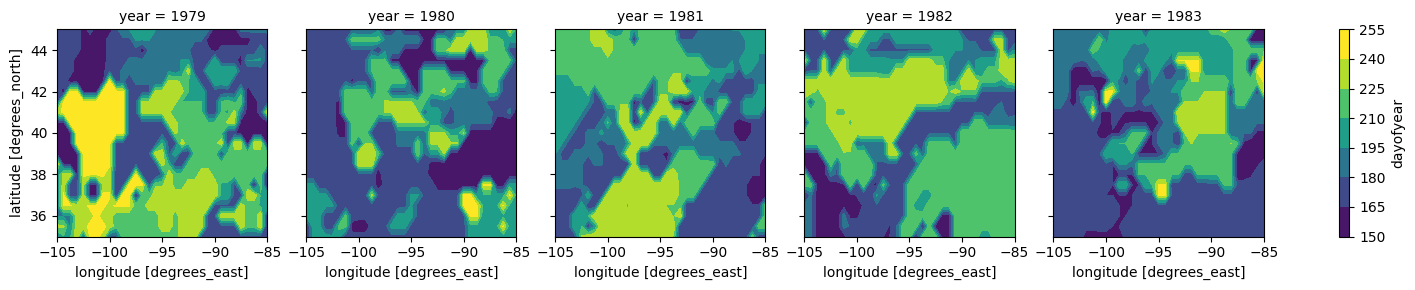

In [87]:
grid_days = Rx1days['PRECT'].dt.dayofyear
grid_days.plot.contourf(col='year', col_wrap=5)
print(len(set_days))

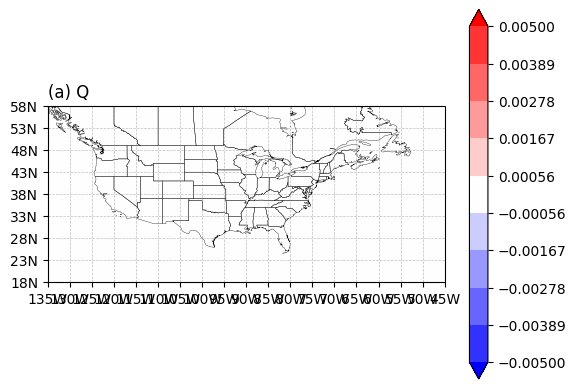

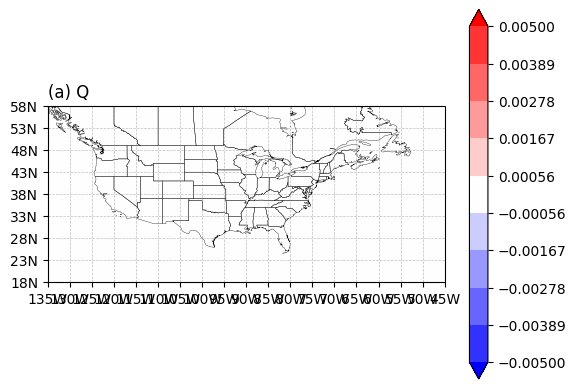

In [15]:
# map_proj = ccrs.PlateCarree()
# levels = np.linspace(-5e-3, 5e-3, 10)
# cmap = cm.bwr
# cmap_kwargs = {'cmap': cmap, 'levels': levels, 'extend': 'both'}
# nrow, ncol = 1, 1
# fig, ax = plt.subplots(nrow, ncol, subplot_kw={'projection': map_proj})
# panel = PanelConfig(0, 'Q', nrow, ncol, projection=map_proj)
# ax, _ = region_plot(anom_fields_on_days['Q'].sel(plev=925, method='nearest'), ax, cmap_kwargs, panel)
# cbar = fig.colorbar(
#     cm.ScalarMappable(norm=mpl.colors.BoundaryNorm(levels, cmap.N, extend='both'), cmap=cmap),
#     ax=ax,
#     orientation='vertical'
# )

# def show(fig):
#     return fig

# show(fig)
# for i, name, da, ax in enumerate(zip(anom_fields_on_days.items(), axs)):
#     panel = PanelConfig(i, name, nrow, ncol, projection=map_proj)
#     ax, _ = region_plot(da.sel()plev, ax, cmap_kwargs, panel)
    
# anom_fields_on_days['Z3'].sel(plev=200, method='nearest').plot.contourf(levels=np.arange(-50, 51, 10), cmap='bwr', extend='both')

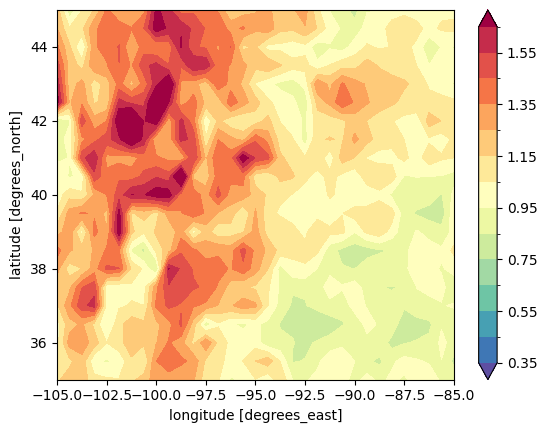

In [65]:
(ctrl_output['Pe'] / ctrl_output['Rx1day']).mean('year').plot.contourf(levels=np.linspace(0.35, 1.65, 14), cmap='Spectral_r', extend='both')

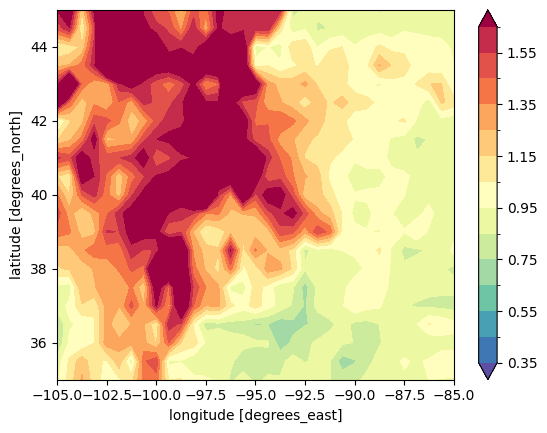

In [66]:
(warm_output['Pe'] / warm_output['Rx1day']).mean('year').plot.contourf(levels=np.linspace(0.35, 1.65, 14), cmap='Spectral_r', extend='both')